In [3]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [20]:
from torch.utils.data import Dataset
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

# Create a custom dataset class for MNIST
class MNISTDataset(Dataset):
    def __init__(self, train=True, transform=None):
        self.train = train

        # Convert images to PyTorch tensors
        self.transform = ToTensor()

        # Load the MNIST dataset
        self.dataset = datasets.MNIST(
            root="./data",            # Dataset location
            train=self.train,         # Train or test data
            transform=self.transform, # Apply transformation
            download=True             # Download if needed
        )

    # Return total number of samples
    def __len__(self):
        return len(self.dataset)

    # Return one image and its label
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label

In [21]:
from torchvision import transforms

# Training augmentation
train_transform = transforms.Compose([
    transforms.RandomRotation(15),                 # Random rotation
    transforms.RandomAffine(0, scale=(0.8, 1.2)),  # Random scaling
    transforms.ToTensor(),                         # Convert to tensor
    transforms.Lambda(
        lambda x: (x + 0.2 * torch.randn_like(x)).clamp(0, 1)
    )                                              # Add random noise
])

# Testing transformation
test_transform = transforms.ToTensor()

In [22]:
# Create datasets
train_dataset = MNISTDataset(
    train=True,
    transform=train_transform
)

test_dataset = MNISTDataset(
    train=False,
    transform=test_transform
)

In [23]:
from torch.utils.data import DataLoader

# Create training dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=128,    # Samples per batch
    shuffle=True       # Shuffle training data
)

# Create testing dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size=128,    # Samples per batch
    shuffle=False      # Keep original order
)

Image size: 28 x 28 x 1 (H x W x C)
Number of classes: 10
Classes: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9


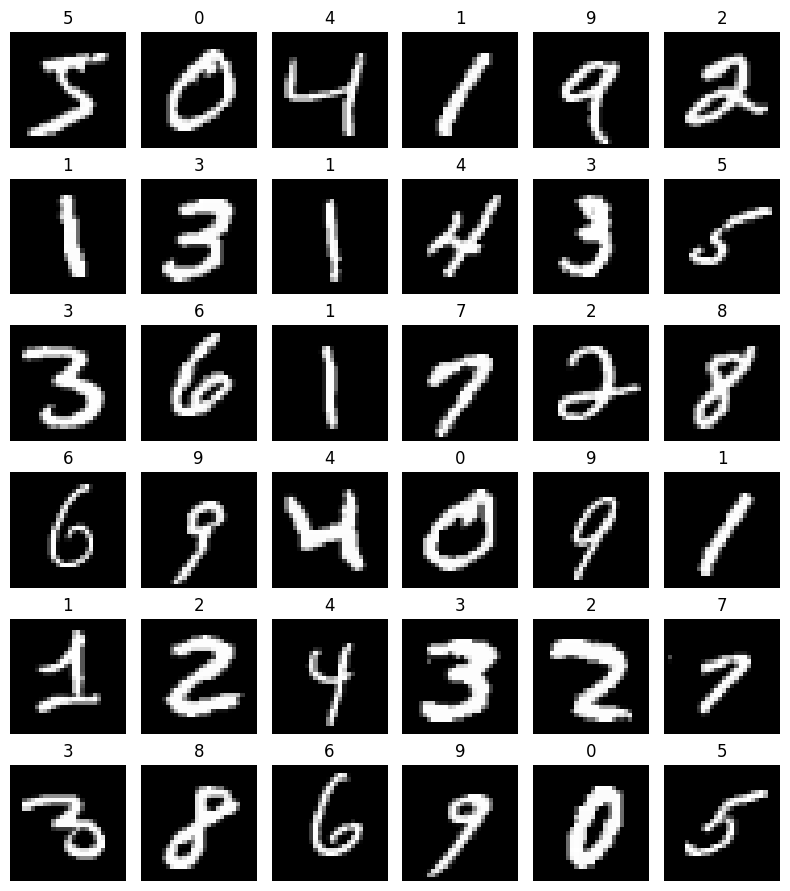

In [24]:
import matplotlib.pyplot as plt
import numpy as np

class Visualize:
    def __init__(self, dataset, classes):
        self.dataset = dataset
        self.classes = classes

    def plot_grid(self, num_images=36):
        """Plot a grid of MNIST images with labels."""
        cols = 6
        rows = int(np.ceil(num_images / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(8, 1.5 * rows))
        axes = axes.flatten()

        for i in range(num_images):
            image, label = self.dataset[i]
            img_np = image.squeeze().numpy()  # Remove channel dimension

            axes[i].imshow(img_np, cmap='gray')
            axes[i].set_title(self.classes[label])
            axes[i].axis("off")

        for i in range(num_images, len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

    def print_metrics(self):
        """Print image size and class names."""
        image, _ = self.dataset[0]
        c, h, w = image.shape

        print(f"Image size: {h} x {w} x {c} (H x W x C)")
        print(f"Number of classes: {len(self.classes)}")
        print(f"Classes: {', '.join(self.classes)}")


# MNIST class names
mnist_classes = [
    "0", "1", "2", "3", "4",
    "5", "6", "7", "8", "9"
]

# Visualize the dataset
visualizer = Visualize(train_dataset, mnist_classes)
visualizer.print_metrics()
visualizer.plot_grid(num_images=36)

In [25]:
import torch
import torch.nn as nn

# Define the CNN model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolutional layers
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),  # (1,28,28) -> (32,26,26)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),      # (32,26,26) -> (32,13,13)

            nn.Conv2d(32, 64, kernel_size=3), # (32,13,13) -> (64,11,11)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)       # (64,11,11) -> (64,5,5)
        )

        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),                     # (64,5,5) -> 1600
            nn.Linear(64 * 5 * 5, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
            # No Softmax here
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


# Create the model
model = CNN()

# Print the model
print(model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1600, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [1]:
data.head()

NameError: name 'data' is not defined